# Exercise 2: Self-Attention and Transformers, SOLUTION

In this exercise, you will build the core components of the **Transformer** architecture (Vaswani et al., 2017) from scratch. You will:

- Understand and implement **Scaled Dot-Product Attention**
- Implement **Multi-Head Attention (MHA)**
- Implement **Positional Encoding**
- Assemble a **Transformer Encoder** block
- Use the Transformer Encoder for **text classification** on the AG News dataset

# **Imports**

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda:0


# **1. Scaled Dot-Product Attention**

Attention is the core mechanism of the Transformer. It allows the model to **focus on different parts of the input** when producing each output.

Given:
- **Query** (Q): what we are looking for
- **Key** (K): what each position offers
- **Value** (V): the actual content at each position

The attention is computed as:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

where $d_k$ is the dimension of the key vectors. We divide by $\sqrt{d_k}$ to prevent the dot products from becoming too large (which would push softmax into regions with very small gradients).

**Task:** Implement scaled dot-product attention step by step.

In [3]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Compute Scaled Dot-Product Attention.
    
    Args:
        Q: Queries, shape (batch_size, seq_len_q, d_k)
        K: Keys, shape (batch_size, seq_len_k, d_k)
        V: Values, shape (batch_size, seq_len_k, d_v)
        mask: Optional mask, shape (batch_size, seq_len_q, seq_len_k)
    Returns:
        output: shape (batch_size, seq_len_q, d_v)
        attention_weights: shape (batch_size, seq_len_q, seq_len_k)
    """
    d_k = Q.size(-1)
    
    # SOLUTION
    # Step 1: Compute attention scores
    scores = torch.matmul(Q, K.transpose(-2, -1))
    
    # Step 2: Scale by sqrt(d_k)
    scores = scores / math.sqrt(d_k)
    
    # Step 3: Apply mask if provided
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    
    # Step 4: Apply softmax
    attention_weights = F.softmax(scores, dim=-1)
    
    # Step 5: Multiply by values
    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights

In [4]:
# Test with a small example
torch.manual_seed(42)

batch_size = 1
seq_len = 4     # 4 words in the sequence
d_k = 8         # dimension of queries/keys
d_v = 8         # dimension of values

Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_v)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"\nAttention weights (each row sums to 1):")
print(attn_weights[0].detach().numpy().round(3))
print(f"Row sums: {attn_weights[0].sum(dim=-1).detach().numpy()}")

Q shape: torch.Size([1, 4, 8])
K shape: torch.Size([1, 4, 8])
V shape: torch.Size([1, 4, 8])
Output shape: torch.Size([1, 4, 8])
Attention weights shape: torch.Size([1, 4, 4])

Attention weights (each row sums to 1):
[[0.194 0.41  0.324 0.071]
 [0.041 0.656 0.086 0.217]
 [0.104 0.206 0.182 0.508]
 [0.193 0.18  0.195 0.432]]
Row sums: [0.9999999 1.        1.        1.       ]


## Visualize Attention Weights

Let's visualize the attention pattern. Each row shows how much attention one position pays to all other positions.

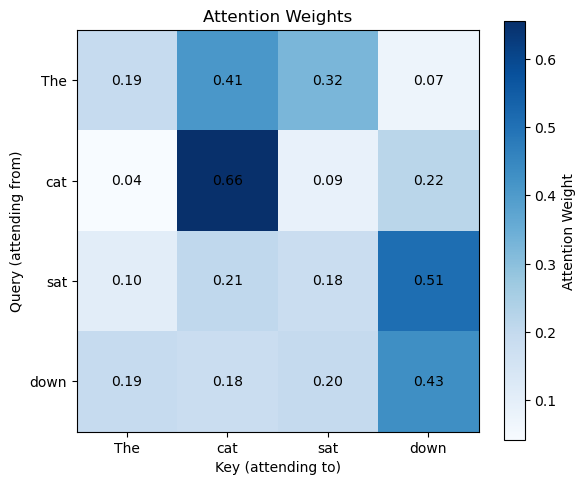

In [5]:
words = ['The', 'cat', 'sat', 'down']

plt.figure(figsize=(6, 5))
plt.imshow(attn_weights[0].detach().numpy(), cmap='Blues')
plt.colorbar(label='Attention Weight')
plt.xticks(range(seq_len), words)
plt.yticks(range(seq_len), words)
plt.xlabel('Key (attending to)')
plt.ylabel('Query (attending from)')
plt.title('Attention Weights')

for i in range(seq_len):
    for j in range(seq_len):
        plt.text(j, i, f'{attn_weights[0,i,j]:.2f}', ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# **2. Multi-Head Attention (MHA)**

Instead of computing a single attention function, Multi-Head Attention runs **multiple attention heads in parallel**, each with its own learned Q, K, V projections. This allows the model to attend to information from different representation subspaces.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O$$

where each head is:
$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

If `d_model = 64` and `num_heads = 4`, then each head operates on `d_k = 64 / 4 = 16` dimensions.

**Task:** Implement Multi-Head Attention as an `nn.Module`.

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        # SOLUTION
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        
    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        
        # SOLUTION
        # Step 1: Apply linear projections
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)
        
        # Step 2: Reshape to (batch_size, num_heads, seq_len, d_k)
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # Step 3: Apply scaled dot-product attention
        attn_output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        
        # Step 4: Reshape back to (batch_size, seq_len, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        # Step 5: Apply output projection
        output = self.W_o(attn_output)
        
        return output, attn_weights

In [7]:
# Test Multi-Head Attention
d_model = 64
num_heads = 4
seq_len = 10
batch_size = 2

mha = MultiHeadAttention(d_model, num_heads)
x = torch.randn(batch_size, seq_len, d_model)

# In self-attention, query = key = value = x
output, attn_weights = mha(x, x, x)

print(f"Input shape:            {x.shape}")           # (2, 10, 64)
print(f"Output shape:           {output.shape}")       # (2, 10, 64)
print(f"Attention weights shape: {attn_weights.shape}") # (2, 4, 10, 10)
print(f"\n=> {num_heads} heads, each producing a {seq_len}x{seq_len} attention matrix")

Input shape:            torch.Size([2, 10, 64])
Output shape:           torch.Size([2, 10, 64])
Attention weights shape: torch.Size([2, 4, 10, 10])

=> 4 heads, each producing a 10x10 attention matrix


## Visualize Multi-Head Attention

Each head learns to attend to different patterns. Let's visualize all heads side by side.

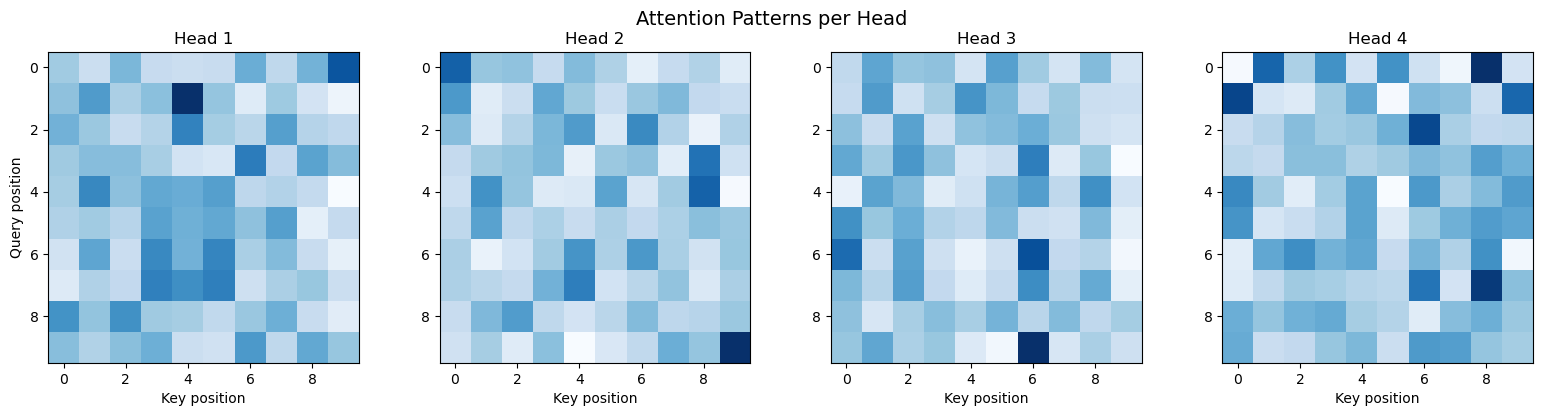

=> Each head learns different attention patterns!


In [8]:
fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))
for h in range(num_heads):
    ax = axes[h]
    im = ax.imshow(attn_weights[0, h].detach().numpy(), cmap='Blues')
    ax.set_title(f'Head {h+1}')
    ax.set_xlabel('Key position')
    if h == 0:
        ax.set_ylabel('Query position')
plt.suptitle('Attention Patterns per Head', fontsize=14)
plt.tight_layout()
plt.show()

print("=> Each head learns different attention patterns!")

# **3. Positional Encoding**

Attention is **permutation-invariant**, it doesn't know the order of the tokens. To inject position information, we add a **positional encoding** to the input embeddings.

The original Transformer uses sinusoidal positional encoding:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

where `pos` is the position in the sequence and `i` is the dimension index.

**Task:** Implement positional encoding.

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        
        # SOLUTION
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Tensor of shape (batch_size, seq_len, d_model)
        Returns:
            x + positional encoding (same shape)
        """
        # SOLUTION
        return x + self.pe[:, :x.size(1), :]

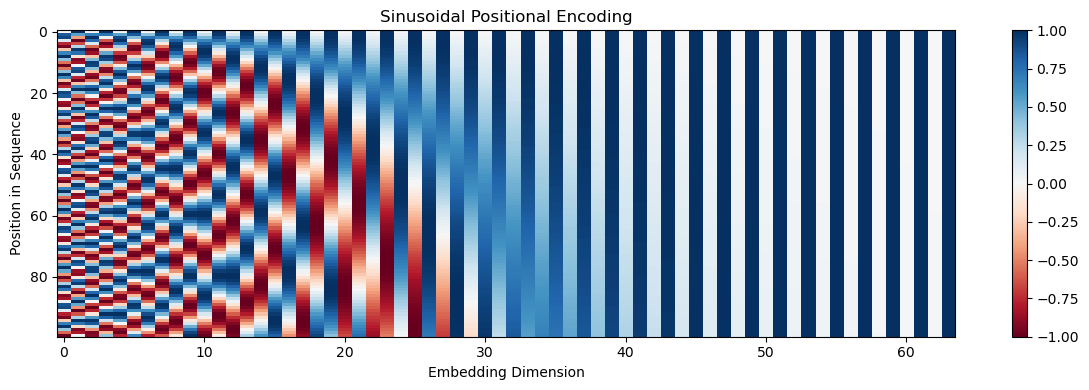

=> Low dimensions oscillate fast (local patterns), high dimensions oscillate slowly (global patterns)


In [10]:
# Visualize the positional encoding
pe = PositionalEncoding(d_model=64, max_len=100)

plt.figure(figsize=(12, 4))
plt.imshow(pe.pe[0, :100, :].numpy(), aspect='auto', cmap='RdBu')
plt.colorbar()
plt.xlabel('Embedding Dimension')
plt.ylabel('Position in Sequence')
plt.title('Sinusoidal Positional Encoding')
plt.tight_layout()
plt.show()

print("=> Low dimensions oscillate fast (local patterns), high dimensions oscillate slowly (global patterns)")

# **4. Transformer Encoder Block**

A Transformer Encoder block consists of:
1. **Multi-Head Self-Attention** + residual connection + LayerNorm
2. **Feed-Forward Network (FFN)** + residual connection + LayerNorm

The FFN is a simple two-layer MLP:
$$\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$$

**Task:** Implement the Transformer Encoder block.

In [11]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        """
        Args:
            d_model: model dimension
            num_heads: number of attention heads
            d_ff: dimension of the feed-forward hidden layer
            dropout: dropout rate
        """
        super().__init__()
        
        # SOLUTION
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        """
        Args:
            x: shape (batch_size, seq_len, d_model)
        Returns:
            output: shape (batch_size, seq_len, d_model)
        """
        # SOLUTION
        # Step 1: Self-Attention with residual connection and LayerNorm
        attn_output, _ = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        
        # Step 2: Feed-Forward with residual connection and LayerNorm
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))
        
        return x

In [12]:
# Test the Transformer Encoder block
encoder_block = TransformerEncoderBlock(d_model=64, num_heads=4, d_ff=128)
x = torch.randn(2, 10, 64)  # (batch_size=2, seq_len=10, d_model=64)

output = encoder_block(x)
print(f"Input shape:  {x.shape}")
print(f"Output shape: {output.shape}")
print(f"\n=> The Transformer Encoder block preserves the input shape!")

Input shape:  torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])

=> The Transformer Encoder block preserves the input shape!


# **5. Text Classification with a Transformer Encoder**

Now let's put everything together and build a Transformer-based text classifier on the **AG News** dataset (4 categories: World, Sports, Business, Sci/Tech).

The model architecture:
1. **Embedding layer**, maps word indices to dense vectors
2. **Positional Encoding**, adds position information
3. **Transformer Encoder blocks** (stacked)
4. **Global average pooling**, average all token representations into one vector
5. **Classification head**, linear layer to predict the class

## 5.1 Prepare the dataset

We will use a simplified text pipeline: split text into words, build a vocabulary from the training set, and convert words to integer indices.

In [13]:
from torchvision.datasets.utils import download_and_extract_archive
import csv
import os
import re
from collections import Counter

# Download AG News dataset
url = 'https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/'

os.makedirs('./data/ag_news', exist_ok=True)

for split in ['train', 'test']:
    filepath = f'./data/ag_news/{split}.csv'
    if not os.path.exists(filepath):
        torch.hub.download_url_to_file(url + f'{split}.csv', filepath)
        print(f'Downloaded {split}.csv')

def read_ag_news(filepath):
    labels, texts = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        for row in reader:
            labels.append(int(row[0]) - 1)  # Convert 1-4 to 0-3
            texts.append(row[1] + ' ' + row[2])  # Title + description
    return texts, labels

train_texts, train_labels = read_ag_news('./data/ag_news/train.csv')
test_texts, test_labels = read_ag_news('./data/ag_news/test.csv')

classes = ['World', 'Sports', 'Business', 'Sci/Tech']
print(f"Training samples: {len(train_texts)}")
print(f"Test samples: {len(test_texts)}")
print(f"\nExample: [{classes[train_labels[0]]}] {train_texts[0][:100]}...")

100.0%


Downloaded train.csv


100.0%

Downloaded test.csv
Training samples: 120000
Test samples: 7600

Example: [Business] Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...


In [14]:
# Build a simple vocabulary from the training set
def simple_tokenizer(text):
    """Lowercase and split on non-alphanumeric characters."""
    return re.findall(r'[a-z0-9]+', text.lower())

# Count word frequencies
word_counts = Counter()
for text in train_texts:
    word_counts.update(simple_tokenizer(text))

# Keep top 20,000 most common words
vocab_size = 20000
most_common = word_counts.most_common(vocab_size - 2)  # Reserve 0=PAD, 1=UNK

word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, _ in most_common:
    word2idx[word] = len(word2idx)

print(f"Vocabulary size: {len(word2idx)}")
print(f"Most common words: {most_common[:10]}")

Vocabulary size: 20000
Most common words: [('the', 205478), ('to', 120746), ('a', 113353), ('of', 98652), ('in', 96425), ('and', 69678), ('s', 61984), ('on', 57667), ('for', 50674), ('39', 44506)]


In [15]:
# Create a dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=64):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        tokens = simple_tokenizer(self.texts[idx])
        # Convert to indices, truncate/pad to max_len
        indices = [self.word2idx.get(t, 1) for t in tokens[:self.max_len]]  # 1 = UNK
        # Pad with 0s
        indices += [0] * (self.max_len - len(indices))
        return torch.tensor(indices, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

max_len = 64
batch_size = 64

train_dataset = TextDataset(train_texts, train_labels, word2idx, max_len)
test_dataset = TextDataset(test_texts, test_labels, word2idx, max_len)

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Check a batch
sample_x, sample_y = next(iter(trainloader))
print(f"Batch input shape:  {sample_x.shape}")  # (64, 64)
print(f"Batch labels shape: {sample_y.shape}")   # (64,)

Batch input shape:  torch.Size([64, 64])
Batch labels shape: torch.Size([64])


## 5.2 Build the Transformer Classifier

**Task:** Assemble the full model using the components you implemented above.

In [16]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_classes, 
                 num_layers=2, max_len=512, dropout=0.1):
        super().__init__()
        
        # SOLUTION
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.classifier = nn.Linear(d_model, num_classes)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        """
        Args:
            x: word indices, shape (batch_size, seq_len)
        Returns:
            logits: shape (batch_size, num_classes)
        """
        # SOLUTION
        # Step 1: Embed tokens
        x = self.embedding(x)
        
        # Step 2: Add positional encoding
        x = self.pos_encoding(x)
        
        # Step 3: Apply dropout
        x = self.dropout(x)
        
        # Step 4: Pass through encoder layers
        for layer in self.encoder_layers:
            x = layer(x)
        
        # Step 5: Global average pooling
        x = x.mean(dim=1)
        
        # Step 6: Classify
        logits = self.classifier(x)
        
        return logits

In [17]:
# Instantiate the model
d_model = 64
num_heads = 4
d_ff = 128
num_layers = 2
num_classes = 4
num_epochs = 5

model = TransformerClassifier(
    vocab_size=len(word2idx), d_model=d_model, num_heads=num_heads,
    d_ff=d_ff, num_classes=num_classes, num_layers=num_layers, 
    max_len=max_len
).to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {num_params:,} trainable parameters")
print(model)

Model has 1,346,692 trainable parameters
TransformerClassifier(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (pos_encoding): PositionalEncoding()
  (encoder_layers): ModuleList(
    (0-1): 2 x TransformerEncoderBlock(
      (attention): MultiHeadAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=False)
        (W_k): Linear(in_features=64, out_features=64, bias=False)
        (W_v): Linear(in_features=64, out_features=64, bias=False)
        (W_o): Linear(in_features=64, out_features=64, bias=False)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=64, bias=True)
      )
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (classifier): Linear(in_features=64, out_features=4, bias=True)
  (dropout): Drop

## 5.3 Training Loop

**Task:** Complete the training loop. This is similar to Lab 4 and 5, forward pass, compute loss, backward pass, optimizer step.

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def compute_run_acc(logits, labels):
    _, pred = torch.max(logits.data, 1)
    return (pred == labels).sum().item()

tr_accuracies = np.zeros(num_epochs)
test_accuracies = np.zeros(num_epochs)
best_test_acc = 0

for epoch_nr in range(num_epochs):
    
    # ---- TRAINING ----
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    
    for batch_data, batch_labels in trainloader:
        # SOLUTION
        batch_data = batch_data.to(device)
        batch_labels = batch_labels.to(device)
        
        optimizer.zero_grad()
        logits = model(batch_data)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_acc += compute_run_acc(logits, batch_labels)
    
    tr_acc = 100 * running_acc / len(trainloader.dataset)
    print(f'TRAIN: Epoch {epoch_nr} | loss: {running_loss/len(trainloader.dataset):.4f} | acc: {tr_acc:.2f}%')
    tr_accuracies[epoch_nr] = tr_acc
    
    # ---- EVALUATION ----
    model.eval()
    running_acc = 0.0
    
    with torch.no_grad():
        for batch_data, batch_labels in testloader:
            # SOLUTION
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)
            
            logits = model(batch_data)
            running_acc += compute_run_acc(logits, batch_labels)
    
    test_acc = 100 * running_acc / len(testloader.dataset)
    print(f'TEST:  Epoch {epoch_nr} | acc: {test_acc:.2f}%')
    test_accuracies[epoch_nr] = test_acc
    
    # Save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), './best_transformer.pth')

print(f'\nFinished Training. Best test accuracy: {best_test_acc:.2f}%')

TRAIN: Epoch 0 | loss: 0.0082 | acc: 80.25%
TEST:  Epoch 0 | acc: 88.14%
TRAIN: Epoch 1 | loss: 0.0049 | acc: 89.23%
TEST:  Epoch 1 | acc: 90.62%
TRAIN: Epoch 2 | loss: 0.0041 | acc: 91.05%
TEST:  Epoch 2 | acc: 91.39%
TRAIN: Epoch 3 | loss: 0.0036 | acc: 92.03%
TEST:  Epoch 3 | acc: 91.58%
TRAIN: Epoch 4 | loss: 0.0032 | acc: 92.94%
TEST:  Epoch 4 | acc: 91.74%

Finished Training. Best test accuracy: 91.74%


## 5.4 Investigate Results

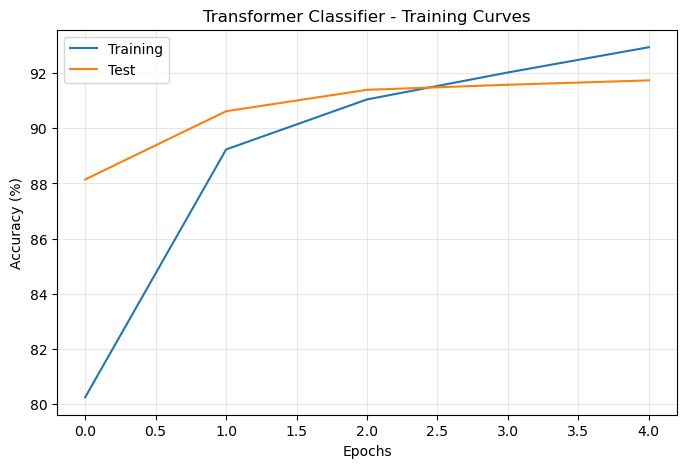

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(tr_accuracies, label='Training')
plt.plot(test_accuracies, label='Test')
plt.ylabel('Accuracy (%)')
plt.xlabel('Epochs')
plt.legend()
plt.title('Transformer Classifier - Training Curves')
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Test on some examples
model.load_state_dict(torch.load('./best_transformer.pth'))
model.eval()

sample_texts = [
    "The stock market crashed today as investors panicked",
    "The football team won the championship after a dramatic final",
    "NASA announced a new mission to explore Mars",
    "The president signed a new peace agreement with neighboring countries",
]

print("Predictions on sample texts:\n")
for text in sample_texts:
    tokens = simple_tokenizer(text)
    indices = [word2idx.get(t, 1) for t in tokens[:max_len]]
    indices += [0] * (max_len - len(indices))
    x = torch.tensor([indices], dtype=torch.long).to(device)
    
    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=1).item()
    
    print(f"  [{classes[pred]:10s}] {text}")

Predictions on sample texts:

  [Business  ] The stock market crashed today as investors panicked
  [World     ] The football team won the championship after a dramatic final
  [Sci/Tech  ] NASA announced a new mission to explore Mars
  [World     ] The president signed a new peace agreement with neighboring countries


**Questions to think about:**
1. How does the Transformer classifier compare to using a simple MLP on bag-of-words features?
2. What is the role of positional encoding? What would happen if we removed it?
3. How does increasing the number of heads or layers affect performance and training time?